##Toy model of an HMM with Tensor Flow Probability

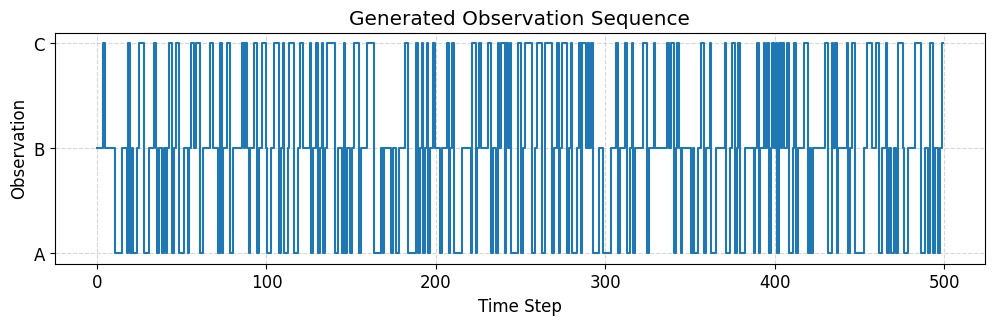

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow_probability import distributions as tfd
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# initial parameters
states = [0, 1, 2]
symbols = ['A', 'B', 'C']
pi = np.array([0.5, 0.2, 0.3])
A = np.array([[0.5, 0.5, 0.0], [0.0, 0.5, 0.5], [0.5, 0.0, 0.5]])
B = np.array([[0.9, 0.1, 0.0], [0.1, 0.8, 0.1], [0.0, 0.2, 0.8]])
T = 500

# Simulate state and observation sequences
state_seq, obs_seq = [], []
current_state = np.random.choice(states, p=pi)
for _ in range(T):
    state_seq.append(current_state)
    obs_seq.append(np.random.choice(symbols, p=B[current_state]))
    current_state = np.random.choice(states, p=A[current_state])

# Plot the true observations
plt.figure(figsize=(12, 3))
plt.step(range(T), [symbols.index(o) for o in obs_seq], where='mid')
plt.yticks([0, 1, 2], symbols)
plt.xlabel('Time Step'); plt.ylabel('Observation')
plt.title('Generated Observation Sequence')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Convert observations to indices
obs_to_idx = {o: i for i, o in enumerate(symbols)}
obs_indices = tf.constant([obs_to_idx[o] for o in obs_seq])

# Initialize trainable parameters (with small noise)
initial_logits = tf.Variable(tf.math.log(pi + 1e-6))
transition_logits = tf.Variable(tf.math.log(A + 1e-6))
emission_logits = tf.Variable(tf.math.log(B + 1e-6))

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        # Build HMM
        hmm = tfd.HiddenMarkovModel(
            initial_distribution=tfd.Categorical(logits=initial_logits),
            transition_distribution=tfd.Categorical(logits=transition_logits),
            observation_distribution=tfd.Categorical(logits=emission_logits),
            num_steps=T
        )
        loss = -hmm.log_prob(obs_indices)  # Negative log likelihood
    grads = tape.gradient(loss, [initial_logits, transition_logits, emission_logits])
    optimizer.apply_gradients(zip(grads, [initial_logits, transition_logits, emission_logits]))
    return loss

# Train
optimizer = tf.optimizers.Adam(learning_rate=0.01)
losses = []
for epoch in range(500):
    loss = train_step()
    losses.append(loss.numpy())
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.2f}")

# Get trained parameters
trained_pi = tf.nn.softmax(initial_logits).numpy()
trained_A = tf.nn.softmax(transition_logits).numpy()
trained_B = tf.nn.softmax(emission_logits).numpy()

Epoch 0, Loss: 489.71
Epoch 50, Loss: 482.92
Epoch 100, Loss: 482.49
Epoch 150, Loss: 482.31
Epoch 200, Loss: 482.22
Epoch 250, Loss: 482.18
Epoch 300, Loss: 482.14
Epoch 350, Loss: 482.07
Epoch 400, Loss: 481.78
Epoch 450, Loss: 481.20


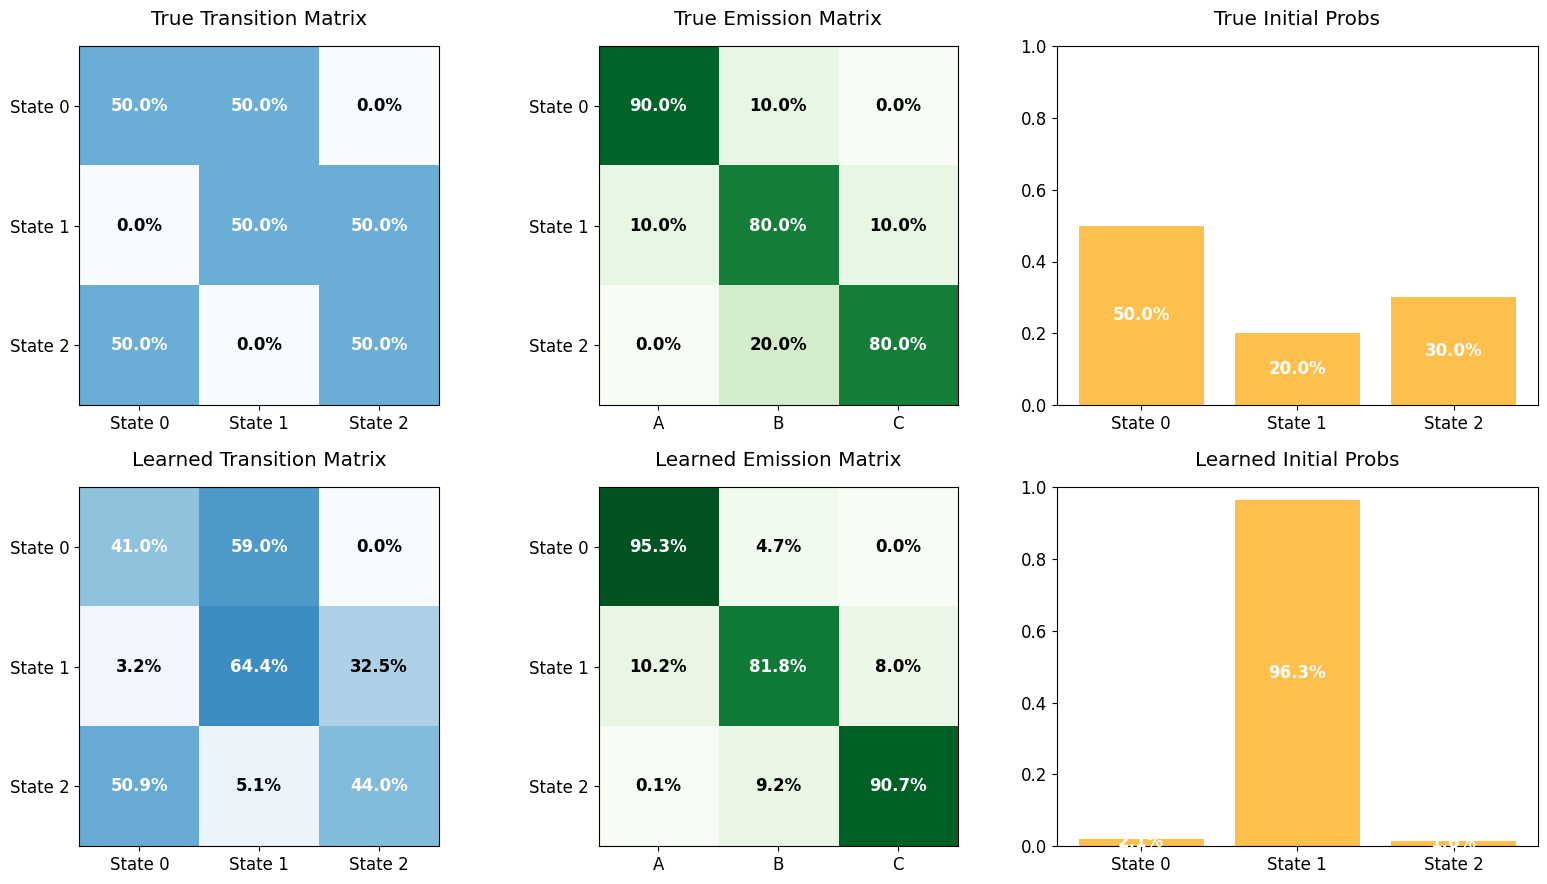

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hmm_parameters(true_A, true_B, true_pi, learned_A, learned_B, learned_pi):
    """Plot HMM parameters with clear percentage annotations"""

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    plt.rcParams.update({'font.size': 12})  # Larger font

    # Custom color thresholds for better readability
    text_colors = [
        {'threshold': 0.4, 'color': 'white'},  # Use white text on dark backgrounds
        {'threshold': 1.0, 'color': 'black'}   # Use black text on light backgrounds
    ]

    def add_percent_annotations(ax, matrix):
        """Add percentage text to matrix cells with automatic color contrast"""
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix[i,j]
                # Choose text color based on cell brightness
                text_color = text_colors[0]['color'] if value > text_colors[0]['threshold'] else text_colors[1]['color']
                ax.text(j, i, f"{value:.1%}",
                        ha='center', va='center',
                        color=text_color, fontweight='bold')

    # --- Transition Matrices ---
    for i, (matrix, title) in enumerate(zip([true_A, learned_A],
                                         ['True Transition Matrix',
                                          'Learned Transition Matrix'])):
        axes[i,0].imshow(matrix, cmap='Blues', vmin=0, vmax=1)
        axes[i,0].set_title(title, pad=15)
        add_percent_annotations(axes[i,0], matrix)
        axes[i,0].set_xticks(range(3))
        axes[i,0].set_yticks(range(3))
        axes[i,0].set_xticklabels(['State 0', 'State 1', 'State 2'])
        axes[i,0].set_yticklabels(['State 0', 'State 1', 'State 2'])

    # --- Emission Matrices ---
    for i, (matrix, title) in enumerate(zip([true_B, learned_B],
                                         ['True Emission Matrix',
                                          'Learned Emission Matrix'])):
        axes[i,1].imshow(matrix, cmap='Greens', vmin=0, vmax=1)
        axes[i,1].set_title(title, pad=15)
        add_percent_annotations(axes[i,1], matrix)
        axes[i,1].set_xticks(range(3))
        axes[i,1].set_yticks(range(3))
        axes[i,1].set_xticklabels(['A', 'B', 'C'])
        axes[i,1].set_yticklabels(['State 0', 'State 1', 'State 2'])

    # --- Initial Probabilities ---
    for i, (probs, title) in enumerate(zip([true_pi, learned_pi],
                                         ['True Initial Probs',
                                          'Learned Initial Probs'])):
        bars = axes[i,2].bar(range(3), probs, color='orange', alpha=0.7)
        axes[i,2].set_title(title, pad=15)
        axes[i,2].set_ylim(0, 1)
        axes[i,2].set_xticks(range(3))
        axes[i,2].set_xticklabels(['State 0', 'State 1', 'State 2'])

        # Add percentage labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[i,2].text(bar.get_x() + bar.get_width()/2., height/2,
                          f"{height:.1%}",
                          ha='center', va='center',
                          color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Example usage with your data:
plot_hmm_parameters(A, B, pi, trained_A, trained_B, trained_pi)

In [ ]:
# Parameter-wise errors
A_error = np.mean(np.abs(A - trained_A))
B_error = np.mean(np.abs(B - trained_B))
pi_error = np.mean(np.abs(pi - trained_pi))

print(f"Transition Matrix Error: {A_error:.4f}")
print(f"Emission Matrix Error: {B_error:.4f}")
print(f"Initial Prob Error: {pi_error:.4f}")

# Viterbi decoding accuracy
viterbi_path = tfd.HiddenMarkovModel(
    initial_distribution=tfd.Categorical(probs=trained_pi),
    transition_distribution=tfd.Categorical(probs=trained_A),
    observation_distribution=tfd.Categorical(probs=trained_B),
    num_steps=T
).posterior_mode(obs_indices).numpy()

accuracy = np.mean(np.array(state_seq) == viterbi_path)
print(f"Viterbi Accuracy: {accuracy:.2%}")

Transition Matrix Error: 0.0722
Emission Matrix Error: 0.0403
Initial Prob Error: 0.5086
Viterbi Accuracy: 86.20%


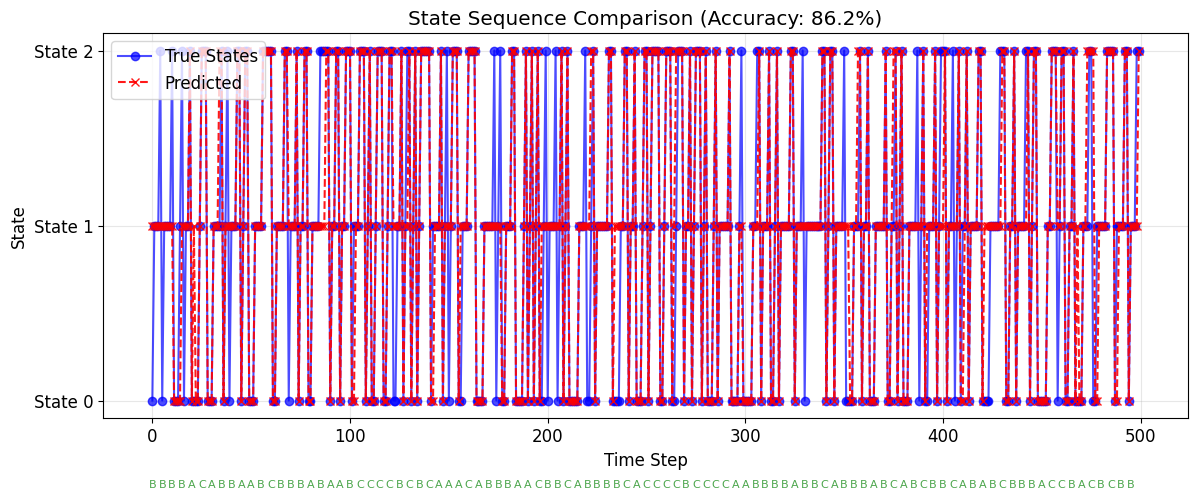

In [ ]:
# VITERBI DECODING
hmm = tfd.HiddenMarkovModel(
    initial_distribution=tfd.Categorical(probs=trained_pi),
    transition_distribution=tfd.Categorical(probs=trained_A),
    observation_distribution=tfd.Categorical(probs=trained_B),
    num_steps=T
)

# Convert observations to indices
obs_to_idx = {o:i for i,o in enumerate(symbols)}
obs_indices = np.array([obs_to_idx[o] for o in obs_seq])

# Get Viterbi path
viterbi_path = hmm.posterior_mode(obs_indices).numpy()


def plot_state_sequences(true_states, predicted_states, observations, T):
    plt.figure(figsize=(14, 5))
    time = np.arange(T)

    # Plot sequences
    plt.plot(time, true_states, 'o-', label='True States',
             color='blue', markersize=6, alpha=0.7)
    plt.plot(time, predicted_states, 'x--', label='Predicted',
             color='red', markersize=6, alpha=0.9)

    # Add observation labels
    for t in range(0, T, 5):  # Every 5 steps
        plt.text(t, -0.5, observations[t], ha='center',
                color='green', fontsize=8, alpha=0.7)

    # Formatting
    plt.yticks([0, 1, 2], ['State 0', 'State 1', 'State 2'])
    plt.xlabel('Time Step')
    plt.ylabel('State')
    plt.title(f'State Sequence Comparison (Accuracy: {np.mean(true_states == predicted_states):.1%})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Generate the plot
plot_state_sequences(state_seq, viterbi_path, obs_seq, T)